<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">1. Decision Trees</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1. Load Data</h3>

In [9]:
import pandas as pd
df = pd.read_csv(r"C:\Users\sadee\OneDrive\Desktop\The Main Folder\The Main Folder\Week 3\Day 4\train_and_test2.csv")# Load the CSV file into a pandas DataFrame
print("Original dataset shape:", df.shape)# Display the dataset size
display(df.head())# Show the first five rows

Original dataset shape: (1309, 28)


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2. Clean The Columns</h3>

In [10]:
# Rename the target column to a clearer name
df = df.rename(columns={"2urvived": "Survived"})

# Find columns that contain only one unique value
constant_columns = [
    column
    for column in df.columns
    if df[column].nunique(dropna=False) == 1
]

print("Constant columns:", constant_columns)
print("Number of constant columns:", len(constant_columns))

# Remove the useless constant columns and the passenger ID
df = df.drop(columns=constant_columns + ["Passengerid"])

# Fill the two missing values in Embarked using the most common value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("Cleaned dataset shape:", df.shape)

display(df.head())

Constant columns: ['zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'zero.15', 'zero.16', 'zero.17', 'zero.18']
Number of constant columns: 19
Cleaned dataset shape: (1309, 8)


,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3. Separating Features from Target</h3>

In [11]:
# Features: the information used to make predictions
X = df.drop(columns="Survived")

# Target: the answer we want the model to predict
y = df["Survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

X shape: (1309, 7)
y shape: (1309,)

Features:
['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked']

Target distribution:
Survived
0    967
1    342
Name: count, dtype: int64
Survived
0    0.739
1    0.261
Name: proportion, dtype: float64


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4. Train/Test Split</h3>

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1047, 7)
X_test shape: (262, 7)
y_train shape: (1047,)
y_test shape: (262,)


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5. Creating and Training a Decision Tree</h3>

In [13]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### How does a point move inside the tree

![alt text](<Screenshot 2026-08-05 192838.png>)

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">6. Making Predictions</h3>

In [14]:
y_pred = tree_model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 actual answers:")
print(y_test.iloc[:10].to_numpy())

First 10 predictions:
[1 0 0 0 0 0 1 0 0 0]

First 10 actual answers:
[0 1 0 0 0 0 0 1 1 0]


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">7. Evaluation of the Model</h3>

In [15]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")

print("\nConfusion Matrix:")
print(matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.756

Confusion Matrix:
[[173  21]
 [ 43  25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       194
           1       0.54      0.37      0.44        68

    accuracy                           0.76       262
   macro avg       0.67      0.63      0.64       262
weighted avg       0.73      0.76      0.74       262



<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">8. Printing Rules as Text</h3>

In [16]:
from sklearn.tree import export_text

tree_rules = export_text(
    tree_model,
    feature_names=list(X.columns)
)

print(tree_rules)

|--- Sex <= 0.50
|   |--- Age <= 4.50
|   |   |--- sibsp <= 2.50
|   |   |   |--- class: 1
|   |   |--- sibsp >  2.50
|   |   |   |--- class: 0
|   |--- Age >  4.50
|   |   |--- Pclass <= 1.50
|   |   |   |--- class: 0
|   |   |--- Pclass >  1.50
|   |   |   |--- class: 0
|--- Sex >  0.50
|   |--- Pclass <= 2.50
|   |   |--- Age <= 42.50
|   |   |   |--- class: 1
|   |   |--- Age >  42.50
|   |   |   |--- class: 0
|   |--- Pclass >  2.50
|   |   |--- Fare <= 24.81
|   |   |   |--- class: 0
|   |   |--- Fare >  24.81
|   |   |   |--- class: 0



<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">9. Drawing the Tree</h3>

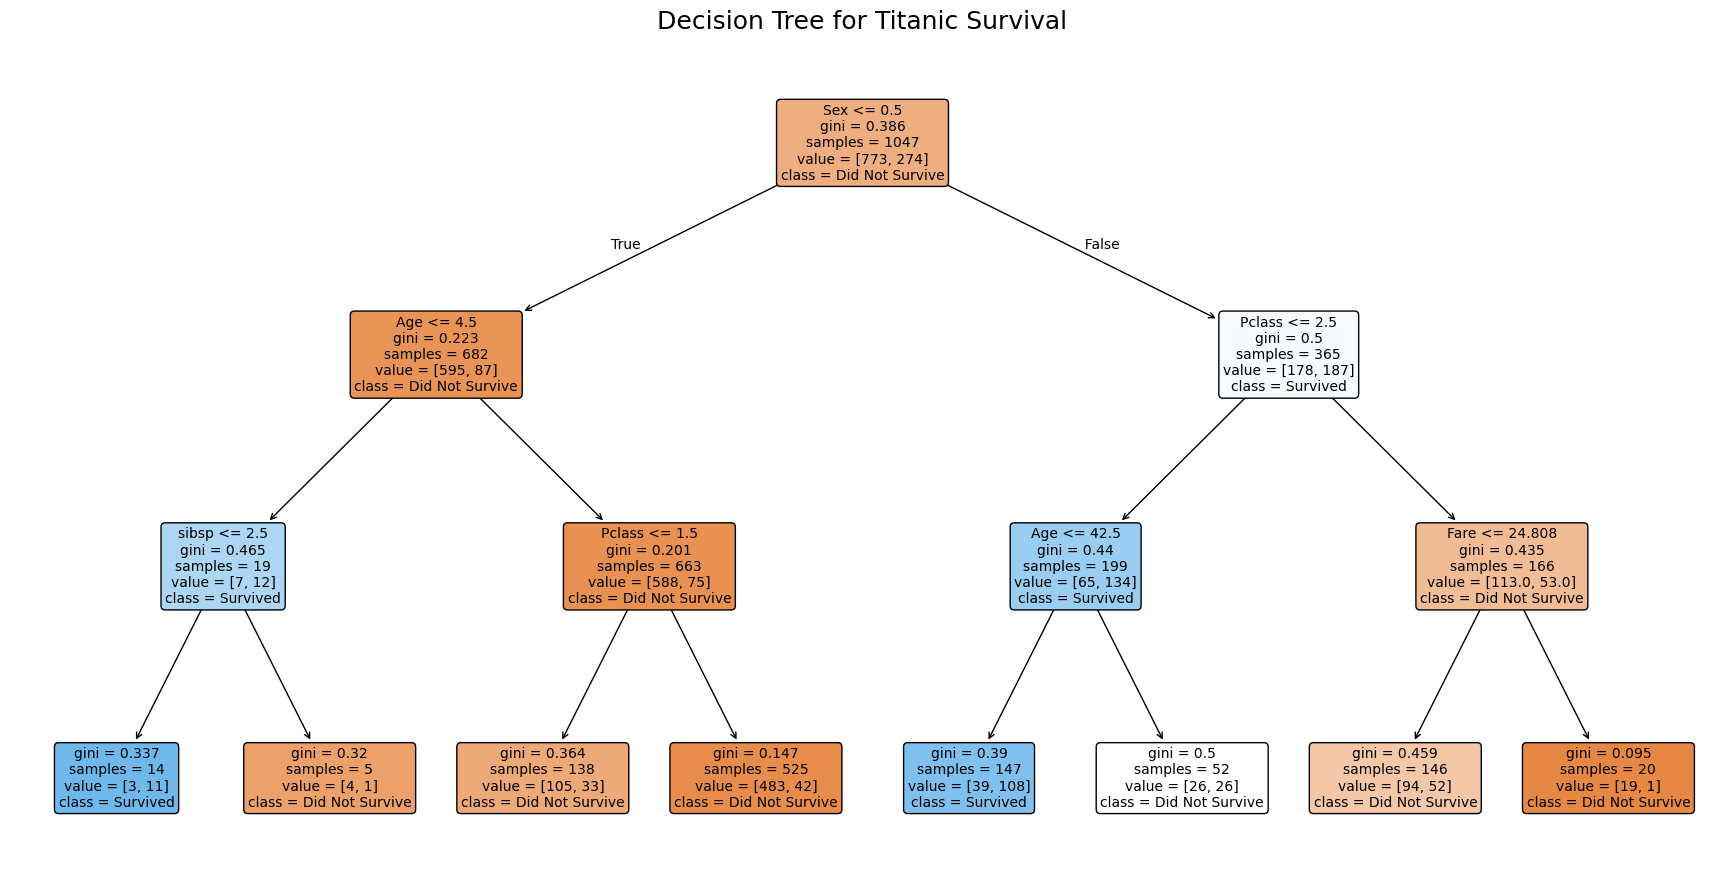

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 11))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Titanic Survival", fontsize=18)
plt.show()

<h2 style="color:#BE185D; font-weight:bold; margin-top:30px; border-top:3px solid #BE185D;">Overfitting</h2>

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depth_results = []

for depth in [1, 2, 3, 5, 10, None]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_accuracy = accuracy_score(
        y_train,
        train_predictions
    )

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    depth_results.append({
        "Max Depth": depth,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })

depth_results_df = pd.DataFrame(depth_results)
display(depth_results_df)

,Max Depth,Train Accuracy,Test Accuracy
0,1.0,0.746896,0.706107
1,2.0,0.808978,0.744275
2,3.0,0.811843,0.755725
3,5.0,0.828080,0.759542
4,10.0,0.904489,0.736641
5,NaN,0.978032,0.732824


<h2 style="color:#BE185D; font-weight:bold; margin-top:30px; border-top:3px solid #BE185D;">2. Random Forest</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1. Applying Random Forest to Titanic data</h3>

In [27]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2. Making Predictions</h3>

In [22]:
random_forest_predictions = random_forest_model.predict(X_test)

print("First 10 predictions:")
print(random_forest_predictions[:10])

print("\nFirst 10 actual answers:")
print(y_test.iloc[:10].to_numpy())

First 10 predictions:
[0 1 0 0 0 0 1 0 0 0]

First 10 actual answers:
[0 1 0 0 0 0 0 1 1 0]


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3. Random Forest Rating</h3>

In [23]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

print(f"Random Forest Accuracy: {random_forest_accuracy:.3f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        random_forest_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        random_forest_predictions
    )
)

Random Forest Accuracy: 0.767

Confusion Matrix:
[[167  27]
 [ 34  34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       194
           1       0.56      0.50      0.53        68

    accuracy                           0.77       262
   macro avg       0.69      0.68      0.69       262
weighted avg       0.76      0.77      0.76       262



<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4. Feature Importances</h3>

In [24]:
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_df)

,Feature,Importance
0,Age,0.334184
1,Fare,0.315987
2,Sex,0.157396
5,Pclass,0.063899
3,sibsp,0.046956
4,Parch,0.046311
6,Embarked,0.035267


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5. Drawing Feature Importances</h3>

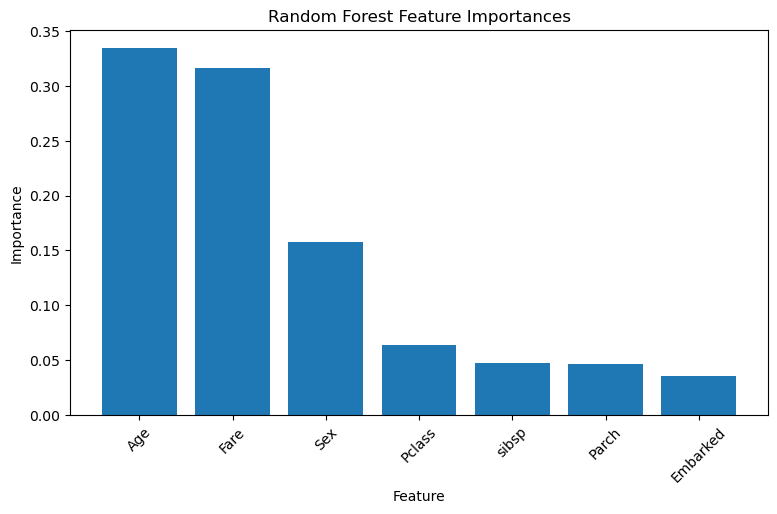

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.title("Random Forest Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

<h2 style="color:#BE185D; font-weight:bold; margin-top:30px; border-top:3px solid #BE185D;">3. Support Vector Machines — SVM</h2>

![alt text](<Screenshot 2026-08-05 211433.png>)

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1. Scale the features</h3>

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2. Create the SVM model & Train the SVM Model</h3>

In [29]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3. Make class predictions</h3>

In [33]:
svm_predictions = svm_model.predict(X_test_scaled)

print("First 10 predictions:")
print(svm_predictions[:10])

print("\nFirst 10 actual answers:")
print(y_test.iloc[:10].to_numpy())

First 10 predictions:
[1 0 0 0 0 0 1 0 0 0]

First 10 actual answers:
[0 1 0 0 0 0 0 1 1 0]


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4. Get positive-class probabilities</h3>

In [36]:
svm_probabilities = svm_model.predict_proba(
    X_test_scaled
)[:, 1]

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5. Calculate evaluation metrics & Display the results</h3>

In [37]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_auc = roc_auc_score(
    y_test,
    svm_probabilities
)

print(f"SVM Accuracy: {svm_accuracy:.3f}")
print(f"SVM ROC-AUC:  {svm_auc:.3f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        svm_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svm_predictions
    )
)

SVM Accuracy: 0.760
SVM ROC-AUC:  0.744

Confusion Matrix:
[[173  21]
 [ 42  26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.85       194
           1       0.55      0.38      0.45        68

    accuracy                           0.76       262
   macro avg       0.68      0.64      0.65       262
weighted avg       0.74      0.76      0.74       262



<h2 style="color:#BE185D; font-weight:bold; margin-top:30px; border-top:3px solid #BE185D;">4. k-Nearest Neighbors — k-NN</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1. Scale The Freatures</h3>

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2. Creating a k-NN model & Train the model</h3>

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3. Making Predictions</h3>

In [41]:
knn_predictions = knn_model.predict(X_test_scaled)

print("First 10 predictions:")
print(knn_predictions[:10])

print("\nFirst 10 actual answers:")
print(y_test.iloc[:10].to_numpy())

First 10 predictions:
[1 0 0 0 0 0 1 0 0 0]

First 10 actual answers:
[0 1 0 0 0 0 0 1 1 0]


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4. Evaluation the k-NN model</h3>

In [42]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print(f"k-NN Accuracy: {knn_accuracy:.3f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        knn_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        knn_predictions
    )
)

k-NN Accuracy: 0.733

Confusion Matrix:
[[163  31]
 [ 39  29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       194
           1       0.48      0.43      0.45        68

    accuracy                           0.73       262
   macro avg       0.65      0.63      0.64       262
weighted avg       0.72      0.73      0.73       262



<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5. Experiment with several values for k</h3>

In [43]:
for k in [1, 3, 5, 7, 9]:
    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    print(
        f"k = {k}: Accuracy = {accuracy:.3f}"
    )

k = 1: Accuracy = 0.721
k = 3: Accuracy = 0.790
k = 5: Accuracy = 0.733
k = 7: Accuracy = 0.771
k = 9: Accuracy = 0.782
